In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("loan_approval_dataset.csv")

In [7]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [8]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [9]:
df.describe()
#residential_assets_value have some negative values which is not possible so we will replace them wiht 0

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [10]:
df.columns.tolist()

['loan_id',
 ' no_of_dependents',
 ' education',
 ' self_employed',
 ' income_annum',
 ' loan_amount',
 ' loan_term',
 ' cibil_score',
 ' residential_assets_value',
 ' commercial_assets_value',
 ' luxury_assets_value',
 ' bank_asset_value',
 ' loan_status']

In [11]:
df.columns = df.columns.str.strip()

In [12]:
#we check how many rows have negative values in residential_assets_value column
df[df["residential_assets_value"]<0]

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
59,60,4,Not Graduate,Yes,5500000,18200000,16,797,-100000,4900000,18600000,4800000,Approved
196,197,4,Not Graduate,Yes,400000,1500000,2,669,-100000,600000,900000,500000,Approved
559,560,2,Graduate,Yes,200000,500000,6,885,-100000,0,300000,200000,Rejected
702,703,4,Graduate,Yes,6300000,23900000,6,899,-100000,11400000,20600000,6700000,Approved
737,738,2,Graduate,Yes,900000,2500000,16,458,-100000,100000,3200000,1100000,Rejected
784,785,0,Graduate,No,5000000,14400000,2,761,-100000,7300000,12600000,4500000,Approved
904,905,2,Graduate,No,4100000,14900000,12,571,-100000,5200000,13000000,3400000,Approved
1089,1090,3,Graduate,No,5100000,11000000,6,336,-100000,5800000,11600000,7500000,Rejected
1163,1164,2,Graduate,No,4500000,9100000,18,593,-100000,600000,12400000,2500000,Approved
1350,1351,5,Graduate,No,4000000,13700000,6,496,-100000,1400000,15800000,3700000,Rejected


In [13]:
print(df[df["residential_assets_value"] < 0].shape[0])
print(df[df["residential_assets_value"] < 0].shape[0] / df.shape[0] * 100)

28
0.65589130944015


In [14]:
df.loc[df["residential_assets_value"] < 0, "residential_assets_value"] = 0
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.473272e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.502878e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,0.000000e+00,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [16]:
print(df.columns.tolist())

['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [17]:
df.columns=df.columns.str.strip()

In [18]:
df["education"].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [19]:
df["self_employed"].value_counts()

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [20]:
df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [21]:
df["self_employed"] = df["self_employed"].str.strip().map({"Yes": 1, "No": 0})
df["education"] = df["education"].str.strip().map({"Graduate": 1, "Not Graduate": 0})
df["loan_status"] = df["loan_status"].str.strip().map({"Approved": 1, "Rejected": 0})

In [ ]:
df[total_assets_value] = df["residential_assets_value"] + df["commercial_assets_value"]

In [22]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [23]:
df.corr()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
loan_id,1.000000,0.005326,0.015536,0.001745,0.012592,0.008170,0.009809,0.016323,0.020944,0.018595,-0.000862,0.010765,0.017685
no_of_dependents,0.005326,1.000000,0.002697,0.000765,0.007266,-0.003366,-0.020111,-0.009998,0.007383,-0.001531,0.002817,0.011163,-0.018114
education,0.015536,0.002697,1.000000,-0.023224,0.011625,0.010631,-0.008417,-0.004649,0.010952,-0.006763,0.012471,0.009424,0.004918
self_employed,0.001745,0.000765,-0.023224,1.000000,0.002368,0.001450,0.004107,-0.004866,0.006151,-0.017998,0.004413,-0.000215,0.000345
income_annum,0.012592,0.007266,0.011625,0.002368,1.000000,0.927470,0.011488,-0.023034,0.636833,0.640328,0.929145,0.851093,-0.015189
loan_amount,0.008170,-0.003366,0.010631,0.001450,0.927470,1.000000,0.008437,-0.017035,0.594589,0.603188,0.860914,0.788122,0.016150
loan_term,0.009809,-0.020111,-0.008417,0.004107,0.011488,0.008437,1.000000,0.007810,0.008012,-0.005478,0.012490,0.017177,-0.113036
cibil_score,0.016323,-0.009998,-0.004649,-0.004866,-0.023034,-0.017035,0.007810,1.000000,-0.019927,-0.003769,-0.028618,-0.015478,0.770518
residential_assets_value,0.020944,0.007383,0.010952,0.006151,0.636833,0.594589,0.008012,-0.019927,1.000000,0.414793,0.590926,0.527410,-0.014379
commercial_assets_value,0.018595,-0.001531,-0.006763,-0.017998,0.640328,0.603188,-0.005478,-0.003769,0.414793,1.000000,0.591128,0.548576,0.008246


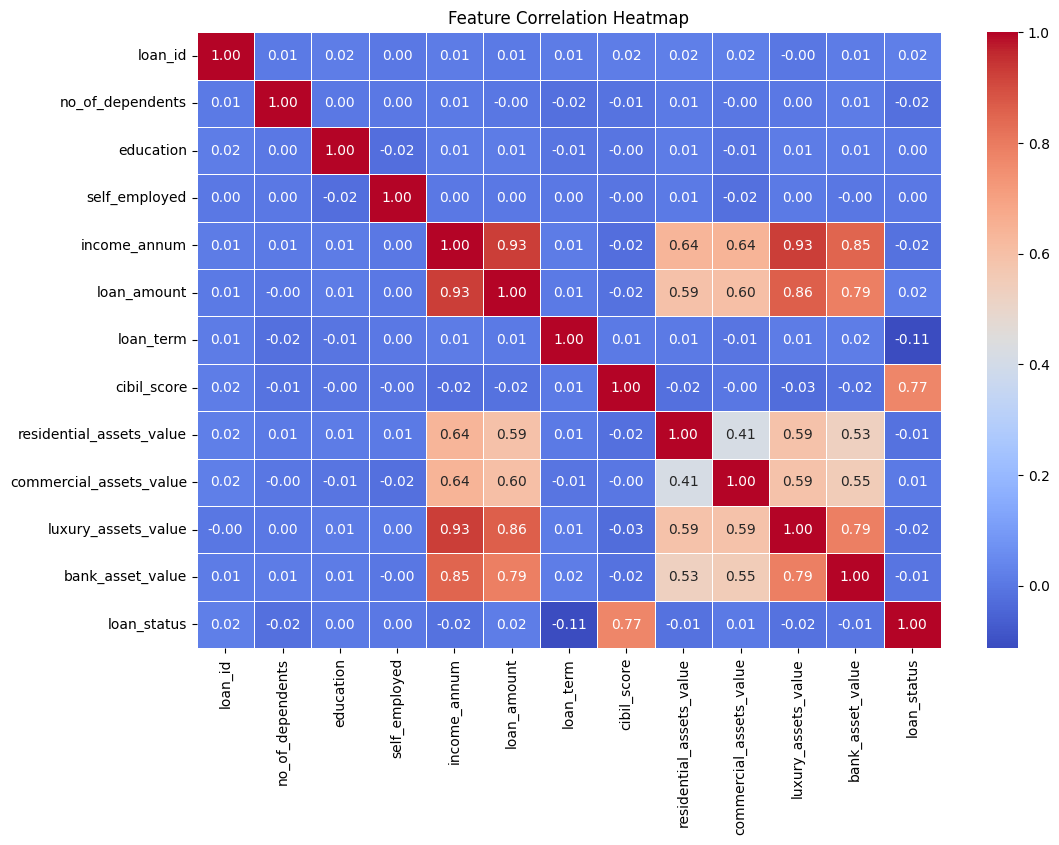

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   int64
 3   self_employed             4269 non-null   int64
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   int64
dtypes: int64(13)
memory usage: 433.7 KB


In [26]:
df=df.drop("loan_id",axis=1)

In [27]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [28]:
print(df.duplicated().sum())

0


In [29]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    print(col, df[col].min(), df[col].max())

no_of_dependents 0 5
education 0 1
self_employed 0 1
income_annum 200000 9900000
loan_amount 300000 39500000
loan_term 2 20
cibil_score 300 900
residential_assets_value 0 29100000
commercial_assets_value 0 19400000
luxury_assets_value 300000 39200000
bank_asset_value 0 14700000
loan_status 0 1


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [31]:
X=df.drop("loan_status", axis=1)
y=df["loan_status"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_test[y_test == 0].head(1)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
1703,5,1,0,5400000,19700000,20,423,6500000,10000000,15700000,7300000


In [30]:
random_forest = RandomForestClassifier(class_weight='balanced')

In [31]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [32]:
y_pred=random_forest.predict(X_test)

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [34]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9824355971896955
[[307  11]
 [  4 532]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       318
           1       0.98      0.99      0.99       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [35]:
random_forest.feature_importances_

array([0.00783459, 0.00238902, 0.00252852, 0.01661626, 0.0288669 ,
       0.05053685, 0.82653813, 0.01691353, 0.01497858, 0.0184727 ,
       0.01432491])

In [36]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

In [37]:
params={ 
             "max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]
}

In [38]:
grid=GridSearchCV(estimator=random_forest, param_grid=params, cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
# grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(class_weight='balanced'),
             n_jobs=-1,
             param_grid={'max_depth': [5, 8, 15, None, 10],
                         'max_features': [5, 7, 'auto', 8],
                         'min_samples_split': [2, 8, 15, 20],
                         'n_estimators': [100, 200, 500, 1000]},
             scoring='accuracy')

In [40]:
grid.best_params_



{'max_depth': 15,
 'max_features': 8,
 'min_samples_split': 2,
 'n_estimators': 500}

In [46]:
random=RandomForestClassifier(class_weight='balanced',max_depth=15,max_features=8,min_samples_split=2,n_estimators=500)

In [47]:
random.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, max_features=8,
                       n_estimators=500)

In [48]:
y_pred2=random.predict(X_test)

In [49]:
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

0.9800936768149883
[[307  11]
 [  6 530]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       318
           1       0.98      0.99      0.98       536

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [50]:
train_pred=random.predict(X_train)

In [51]:
print(accuracy_score(y_train,train_pred))

1.0


In [52]:
import pickle

In [53]:
pickle.dump(random,open('random.pkl','wb'))